<a href="https://colab.research.google.com/github/Arx15E/University-Proyects/blob/main/Parcial_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Gestión de Riesgo Clínico – Integración Sede Sabaneta**

Esta entidad busca mejorar la eficiencia operativa mediante la reubicación técnica de su población clínica en sedes con perfiles epidemiológicos afines.

El comportamiento de este traslado se describe a través de la variable de referencia (Diabetes), la cual permite caracterizar la población antes y después de la integración utilizando medidas de tendencia central (media, mediana) y de dispersión (desviación estándar, varianza).

Para la ejecución de este procedimiento, se aplicarán las siguientes técnicas de analítica de datos:


Teoría de la Credibilidad: Determina la afinidad estadística entre la sucursal a cerrar (Sabaneta) y las sedes receptoras, evaluando qué tan "creíbles" o compatibles son los datos externos frente a la estructura interna de cada sede.


Método de Valor de Pertenencia: Clasifica a los pacientes basándose en su grado de ajuste a la distribución de la nueva sede.

Este espacio de trabajo ha ejecutado las fases del proceso de integración de pacientes de la sucursal Sabaneta en otras sedes con perfiles epidemiológicos afines. A continuación, se detallan los resultados obtenidos en cada etapa:


### **1. Carga y Preparación de Datos:**
Se han cargado los datos de las diferentes sucursales desde el archivo Excel `medical_attention_data.xlsx`. Se consolidó la información de todas las hojas en un único DataFrame, asegurando la correcta identificación de la sucursal de origen (`Branch`) para cada paciente.


### **2. Caracterización Estadística Pre-Integración (Análisis de Momentos Inicial):**
Antes de la integración, se caracterizó estadísticamente la variable de referencia (`Diabetes`) para cada sucursal, calculando la media, desviación estándar, asimetría y curtosis. Este análisis permitió entender las distribuciones de la población de pacientes en cada sede y en Sabaneta (sede a clausurar).


### **3. Estimación de la Afinidad (Teoría de la Credibilidad):**
Se aplicó la Teoría de la Credibilidad para determinar la afinidad estadística entre la sucursal Sabaneta y las demás sedes. Se calculó un factor 'Z' para cada sucursal receptora, identificando a **Medellín** como la sede con mayor afinidad para recibir a los pacientes de Sabaneta, debido a la compatibilidad de sus perfiles de riesgo en la variable 'Diabetes'.


### **4. Integración por el Método de Aceptación y Rechazo:**
Utilizando la sede de mayor afinidad (Medellín) como referencia, se aplicó el método de Aceptación y Rechazo a los pacientes de Sabaneta. Este método permitió seleccionar aquellos registros que, al ser integrados, mantienen la estructura intrínseca de la variable de referencia (`Diabetes`) en la sede receptora, evitando distorsiones significativas. El proceso es análogo a un muestreo aleatorio con "ruleta cargada", donde la probabilidad de aceptación depende del ajuste a la distribución de la sede receptora.


### **5. Consolidación y Validación Post-Integración (Análisis de Momentos Final):**
Finalmente, se consolidaron los pacientes aceptados de Sabaneta con los datos de las sedes restantes (excluyendo los pacientes rechazados de Sabaneta y la propia sede Sabaneta). Se realizó un nuevo análisis estadístico de la variable de referencia (`Diabetes`) para evaluar el impacto de la integración. Los resultados muestran la nueva distribución de pacientes y sus momentos estadísticos en la sede integrada (Medellín), confirmando el efecto de la reubicación.

In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from google.colab import drive

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/IntegraciónDatos/3. Parcial - medical_attention_data.xlsx'
xls = pd.ExcelFile(file_path)
sheet_names = xls.sheet_names

all_dfs = []

for sheet_name in sheet_names:
    temp_df = pd.read_excel(xls, sheet_name=sheet_name)
    temp_df['Branch'] = sheet_name
    all_dfs.append(temp_df)

df = pd.concat(all_dfs, ignore_index=True)

print("Datos cargados y consolidados de todas las sucursales:")
print(df.head())
print("\nInformación del DataFrame consolidado:")
df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datos cargados y consolidados de todas las sucursales:
  PatientID  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
0  BEL-0001    167.0             44             50      135  19.375   
1  BEL-0002     60.0             54             12      602  43.115   
2  BEL-0003    104.0             89             13      845  21.230   
3  BEL-0004     72.0             61             12      145  49.781   
4  BEL-0005     68.0             75             58      529  45.160   

   DiabetesPedigreeFunction  Age  Diabetes Branch  Pregnancies  
0                     0.788   49         0  Bello          NaN  
1                     1.640   37         1  Bello          NaN  
2                     1.958   35         1  Bello          NaN  
3                     1.643   25         1  Bello          NaN  
4                     0.471   79         1  Bello          NaN  

## Definición de Variables de Configuración

Se establecen las variables `sede_clausura` (la sucursal que se cerrará) y `variable_referencia` (la variable clave para el análisis de riesgo).

In [56]:
sede_clausura = 'Sabaneta'
variable_referencia = 'Diabetes'

print(f"Sede de clausura establecida como: {sede_clausura}")
print(f"Variable de referencia establecida como: {variable_referencia}")

Sede de clausura establecida como: Sabaneta
Variable de referencia establecida como: Diabetes


## 1. Caracterización Estadística Pre-Integración (Análisis de Momentos Inicial)

Se realiza un análisis estadístico descriptivo de la variable de referencia para cada sucursal antes de la integración, calculando la media, desviación estándar, asimetría, curtosis y el número de pacientes.

In [57]:
print("### ANÁLISIS DE MOMENTOS - ESTADO INICIAL ###")
stats_pre = df.groupby('Branch')[variable_referencia].agg(['mean', 'std', 'skew', pd.Series.kurt, 'count'])
stats_pre.columns = ['Media', 'Desviación', 'Asimetría', 'Kurtosis', 'N_Pacientes']
print(stats_pre)

### ANÁLISIS DE MOMENTOS - ESTADO INICIAL ###
             Media  Desviación  Asimetría  Kurtosis  N_Pacientes
Branch                                                          
Bello     0.490040    0.500399   0.039968 -2.006412          502
Caldas    0.484048    0.500021   0.063944 -2.000317          909
Envigado  0.486111    0.500123   0.055683 -2.001961          792
Itagui    0.505848    0.500332  -0.023445 -2.005322          684
Medellín  0.471508    0.499467   0.114344 -1.991381          895
Sabaneta  0.510467    0.500293  -0.041979 -2.004705          621


## Correlación entre Variables

Se calcula y visualiza la matriz de correlación entre todas las variables numéricas del DataFrame consolidado para entender sus interrelaciones.


### MATRIZ DE CORRELACIÓN ###
                           Glucose  BloodPressure  SkinThickness   Insulin  \
Glucose                   1.000000       0.013956      -0.006072  0.015633   
BloodPressure             0.013956       1.000000      -0.007808  0.005684   
SkinThickness            -0.006072      -0.007808       1.000000 -0.021895   
Insulin                   0.015633       0.005684      -0.021895  1.000000   
BMI                      -0.039272      -0.008646       0.025596 -0.008352   
DiabetesPedigreeFunction -0.021183      -0.011843       0.011530 -0.009968   
Age                       0.004046      -0.003388       0.007822 -0.001410   
Diabetes                 -0.000049       0.001454       0.017592 -0.001180   
Pregnancies               0.015691      -0.009923      -0.005091  0.029169   

                               BMI  DiabetesPedigreeFunction       Age  \
Glucose                  -0.039272                 -0.021183  0.004046   
BloodPressure            -0.008646      

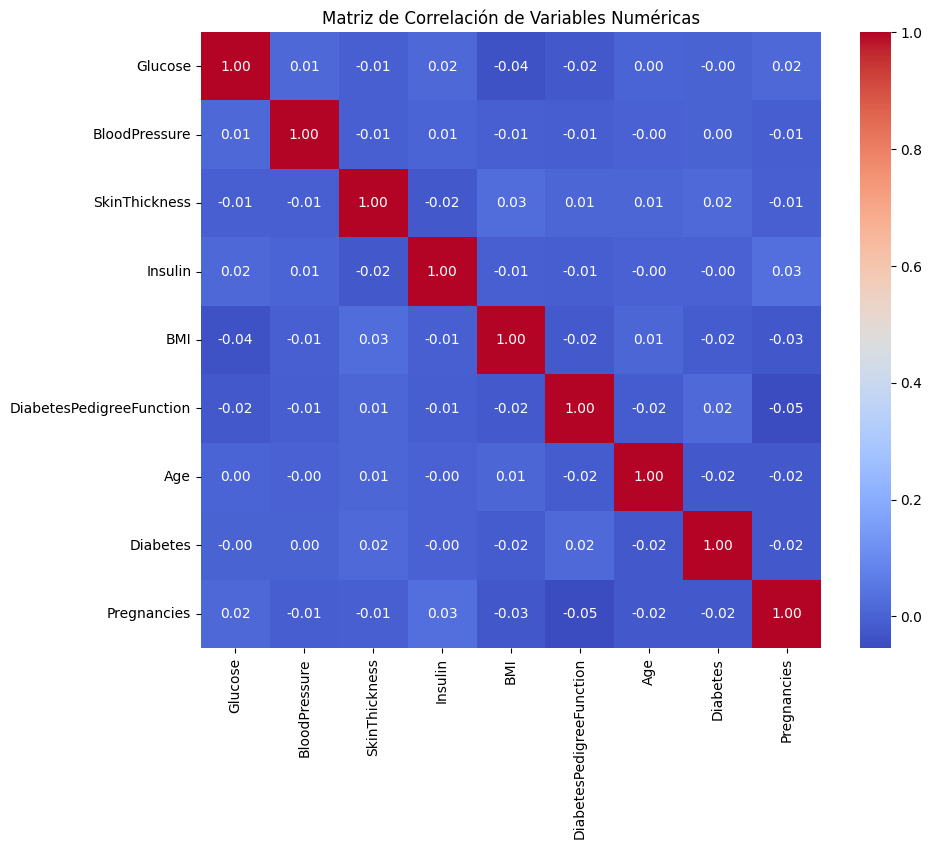

In [58]:
print("\n### MATRIZ DE CORRELACIÓN ###")

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

correlation_matrix = df[numeric_cols].corr()
print(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

## 2. Estimación de la Afinidad (Teoría de la Credibilidad)

Se aplica la Teoría de la Credibilidad para determinar la afinidad estadística entre la sucursal a cerrar (Sabaneta) y las demás sedes, evaluando su compatibilidad de datos.

In [63]:
def calcular_credibilidad(n_orig, var_orig, var_dest):
    k = var_dest / var_orig
    return n_orig / (n_orig + k)

df_sabaneta = df[df['Branch'] == sede_clausura].copy()
df_otras = df[df['Branch'] != sede_clausura].copy()

n_sabaneta = len(df_sabaneta)
var_sabaneta = df_sabaneta[variable_referencia].var()
sucursales_destino = df_otras['Branch'].unique()

credibilidad_dict = {}
for suc in sucursales_destino:
    var_suc = df_otras[df_otras['Branch'] == suc][variable_referencia].var()
    credibilidad_dict[suc] = calcular_credibilidad(n_sabaneta, var_sabaneta, var_suc)

if credibilidad_dict:
    sede_afinidad = max(credibilidad_dict, key=credibilidad_dict.get)
    z_valor = credibilidad_dict[sede_afinidad]

    print(f"\n--- RESULTADOS DE CREDIBILIDAD ---")
    for s, z in credibilidad_dict.items():
        print(f"Sucursal: {s} | Factor Z: {z:.4f}")
    print(f"\nSede elegida por afinidad: {sede_afinidad} (Z = {z_valor:.4f})")



--- RESULTADOS DE CREDIBILIDAD ---
Sucursal: Bello | Factor Z: 0.9984
Sucursal: Medellín | Factor Z: 0.9984
Sucursal: Envigado | Factor Z: 0.9984
Sucursal: Itagui | Factor Z: 0.9984
Sucursal: Caldas | Factor Z: 0.9984

Sede elegida por afinidad: Medellín (Z = 0.9984)


## 3. Integración por el Método de Aceptación y Rechazo

Utilizando la sede de mayor afinidad, se aplica el método de Aceptación y Rechazo para seleccionar a los pacientes de Sabaneta que serán integrados, asegurando que la estructura intrínseca de la variable de referencia en la sede receptora no se distorsione.

In [60]:
if sede_afinidad:
    # Definición de parámetros para el muestreo (f(x) vs g(x))
    mu_ref = df_otras[df_otras['Branch'] == sede_afinidad][variable_referencia].mean()
    std_ref = df_otras[df_otras['Branch'] == sede_afinidad][variable_referencia].std()
    mu_total = df[variable_referencia].mean()
    std_total = df[variable_referencia].std()

    c = 1.2 # Constante de escala
    np.random.seed(42)

    # Algoritmo de Aceptación y Rechazo
    f_x = norm.pdf(df_sabaneta[variable_referencia], mu_ref, std_ref)
    g_x = norm.pdf(df_sabaneta[variable_referencia], mu_total, std_total)

    # Se añade una pequeña constante para evitar divisiones por cero en g_x si algún valor es 0
    epsilon = 1e-9
    df_sabaneta['Aceptado'] = (f_x / (c * (g_x + epsilon))) > np.random.uniform(0, 1, len(df_sabaneta))
    print(f"Método de Aceptación y Rechazo aplicado. {df_sabaneta['Aceptado'].sum()} pacientes de Sabaneta aceptados para integración en {sede_afinidad}.")
else:
    print("Sede de afinidad no determinada, se omite el método de Aceptación y Rechazo.")

Método de Aceptación y Rechazo aplicado. 505 pacientes de Sabaneta aceptados para integración en Medellín.


## 4. Consolidación y Validación Post-Integración (Análisis de Momentos Final)

Finalmente, se consolidan los pacientes aceptados de Sabaneta con los datos de las sedes restantes. Se realiza un nuevo análisis estadístico de la variable de referencia para evaluar el impacto de la integración y se visualiza el cambio en la distribución.


### ANÁLISIS DE MOMENTOS - ESTADO POST-INTEGRACIÓN ###
             Media  Desviación  Asimetría  Kurtosis  N_Pacientes
Branch                                                          
Bello     0.490040    0.500399   0.039968 -2.006412          502
Caldas    0.484048    0.500021   0.063944 -2.000317          909
Envigado  0.486111    0.500123   0.055683 -2.001961          792
Itagui    0.505848    0.500332  -0.023445 -2.005322          684
Medellín  0.474286    0.499517   0.103104 -1.992218         1400


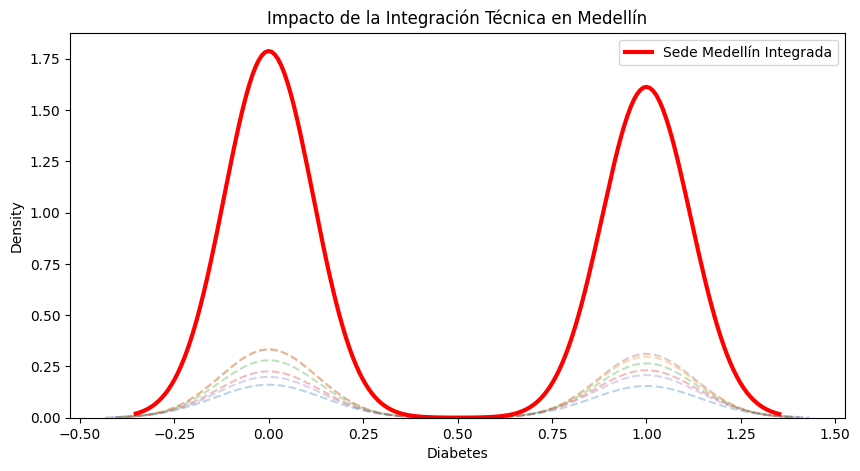

In [61]:
if sede_afinidad:
    df_integrados = df_sabaneta[df_sabaneta['Aceptado'] == True].copy()
    df_integrados['Branch'] = sede_afinidad

    # Excluir los pacientes de Sabaneta (los aceptados ya están en df_integrados, los rechazados no se usan)
    df_otras_sin_sabaneta = df_otras[df_otras['Branch'] != sede_clausura].copy()
    df_final = pd.concat([df_otras_sin_sabaneta, df_integrados])

    print("\n### ANÁLISIS DE MOMENTOS - ESTADO POST-INTEGRACIÓN ###")
    stats_post = df_final.groupby('Branch')[variable_referencia].agg(['mean', 'std', 'skew', pd.Series.kurt, 'count'])
    stats_post.columns = ['Media', 'Desviación', 'Asimetría', 'Kurtosis', 'N_Pacientes']
    print(stats_post)

    # Visualización del impacto en la distribución
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=df, x=variable_referencia, hue='Branch', alpha=0.3, linestyle="--")
    sns.kdeplot(data=df_final[df_final['Branch'] == sede_afinidad], x=variable_referencia, color='red', label=f'Sede {sede_afinidad} Integrada', linewidth=3)
    plt.title(f"Impacto de la Integración Técnica en {sede_afinidad}")
    plt.legend()
    plt.show()
else:
    print("No se pudo determinar una sede de afinidad, la integración no se realizará.")

In [65]:
print(stats_post)

             Media  Desviación  Asimetría  Kurtosis  N_Pacientes
Branch                                                          
Bello     0.490040    0.500399   0.039968 -2.006412          502
Caldas    0.484048    0.500021   0.063944 -2.000317          909
Envigado  0.486111    0.500123   0.055683 -2.001961          792
Itagui    0.505848    0.500332  -0.023445 -2.005322          684
Medellín  0.474286    0.499517   0.103104 -1.992218         1400


In [66]:
medellin_pre_stats = stats_pre.loc['Medellín'].to_frame().T
medellin_post_stats = stats_post.loc['Medellín'].to_frame().T

# Add a label to distinguish between pre and post
medellin_pre_stats.index = ['Medellín (Pre-Integración)']
medellin_post_stats.index = ['Medellín (Post-Integración)']

comparison_medellin = pd.concat([medellin_pre_stats, medellin_post_stats])

print("### Comparación de Estadísticas para Medellín (Pre y Post-Integración) ###")
print(comparison_medellin)

### Comparación de Estadísticas para Medellín (Pre y Post-Integración) ###
                                Media  Desviación  Asimetría  Kurtosis  \
Medellín (Pre-Integración)   0.471508    0.499467   0.114344 -1.991381   
Medellín (Post-Integración)  0.474286    0.499517   0.103104 -1.992218   

                             N_Pacientes  
Medellín (Pre-Integración)         895.0  
Medellín (Post-Integración)       1400.0  


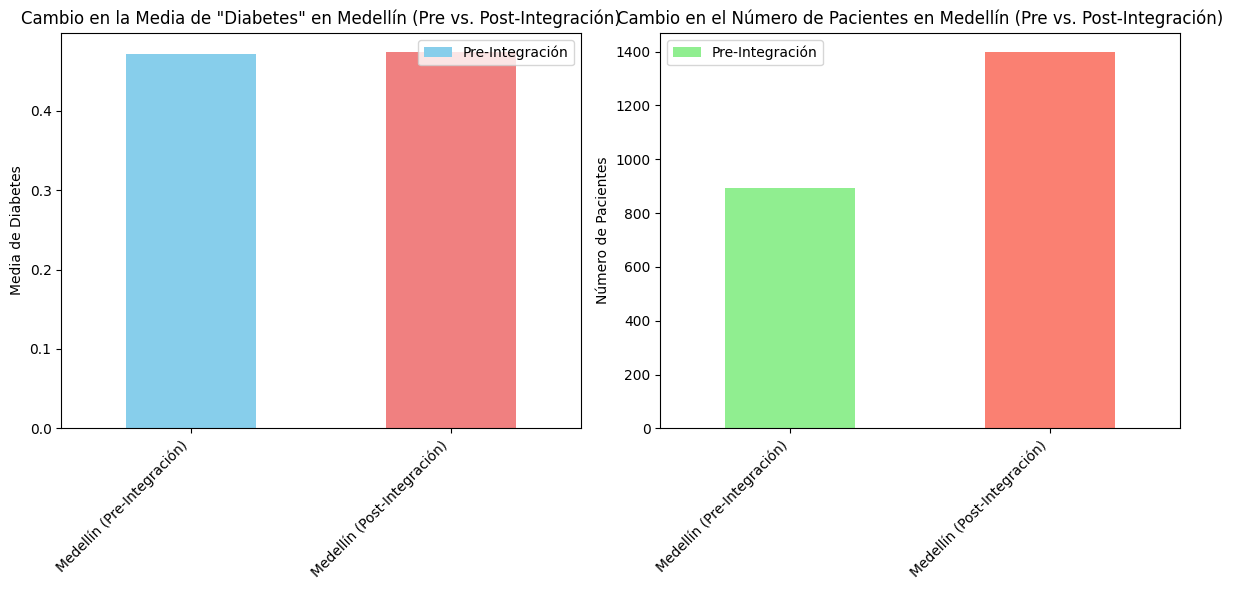

In [67]:
plt.figure(figsize=(12, 6))

# Gráfico para la Media
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
comparison_medellin['Media'].plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Cambio en la Media de "Diabetes" en Medellín (Pre vs. Post-Integración)')
plt.ylabel('Media de Diabetes')
plt.xticks(rotation=45, ha='right')
plt.legend(['Pre-Integración', 'Post-Integración'])

# Gráfico para el Número de Pacientes
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
comparison_medellin['N_Pacientes'].plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('Cambio en el Número de Pacientes en Medellín (Pre vs. Post-Integración)')
plt.ylabel('Número de Pacientes')
plt.xticks(rotation=45, ha='right')
plt.legend(['Pre-Integración', 'Post-Integración'])

plt.tight_layout()
plt.show()